# Adaptive Honeypot Deception for Detecting Stealthy and Human-Like Cyber Intrusions
### Exhaustive Experimental Notebook

**Companion to the manuscript** *"Adaptive Honeypot Deception for Detecting Stealthy and Human-Like Cyber Intrusions: A Behavioral-Separability Framework"* (Alsharabi, Alanzi, Hamam).

This notebook is fully self-contained and reproduces **every number, table, and figure** in the paper. It is organized in the 25 modules of the experimental campaign:

| Modules | Content |
|---|---|
| 01 | Configuration |
| 02–06 | Legitimate-user, naive, stealth, human-like attacker generators (mimicry operator $\mathcal{M}_\lambda$) |
| 07–08 | Decoy tiers and event-sequence generation |
| 09 | Feature engineering (19 features, 4 families) |
| 10 | Behavioral Separability Index and detectability bounds (Props. 1–2) |
| 11–12 | Supervised models and anomaly-detection baseline (E1, E2) |
| 13 | Attacker realism sweep + empirical bound verification (E3) |
| 14 | Hard negatives and per-profile performance (E4–E5) |
| 15 | Leave-one-attacker-strategy-out (E6) |
| 16 | Feature ablation and importance (E7) |
| 17 | Sequential early detection, TTD, EWS (E8) |
| 18 | Evasion cost / attacker utility |
| 19 | Adaptive deception (risk-conditioned decoys) — lightweight demonstration |
| 20 | Probability calibration |
| 21 | Class-imbalance and telemetry-noise robustness |
| 22 | Statistical tests |
| 23–25 | Tables, figures, summary of outputs |

Runtime: roughly 15–25 minutes on a standard machine or Google Colab CPU runtime.

## 01 — Configuration

In [1]:
# 01_configuration
import os, sys, json, warnings, pickle
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy import stats as scistats
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, average_precision_score, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 9.5, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
BLUE,RED,GREEN,ORANGE,PURPLE,GRAY = "#2166ac","#b2182b","#1b7837","#e08214","#762a83","#666666"

# Output tree (plan §44). Uses Google Drive when running on Colab, else local.
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/MyDrive/Outputs/Adaptive_Honeypot_Deception"
else:
    ROOT = "./Outputs/Adaptive_Honeypot_Deception"
DIRS = {k: os.path.join(ROOT, k) for k in ["Data/Generated","Data/Splits","Figures","Tables","Models"]}
for d in DIRS.values(): os.makedirs(d, exist_ok=True)
T, F, DG, MO = DIRS["Tables"]+"/", DIRS["Figures"]+"/", DIRS["Data/Generated"]+"/", DIRS["Models"]+"/"
SEED = 42
print("Output root:", ROOT)

Output root: ./Outputs/Adaptive_Honeypot_Deception


## 02–06 — Session Generators: Legitimate Users, Hard Negatives, and the Attacker Realism Continuum

Sessions are generated as **ordered event sequences** (marked temporal point processes, Eq. (1) of the paper); aggregate features are derived afterwards, so session-level and sequential experiments share identical data.

The **mimicry operator** $\mathcal{M}_\lambda(\theta_{\mathrm{mal}}) = (1-\lambda)\theta_{\mathrm{mal}} + \lambda\theta_{\mathrm{norm}}$ interpolates attacker behavioral parameters between naive automation ($\lambda=0$) and a normal-like operating point ($\lambda=1$). Profiles A0–A4 are sampled points on this path; A2+ additionally defeats the off-hours heuristic, A3+ suppresses obvious keyword searches and interacts with decoys selectively and late.

The legitimate population mixes five roles (clerk, admin, developer, finance, new hire) and six **hard-negative** scenarios (benign sessions that superficially resemble attacks). Unlike the original study's generator — in which normal users *never* searched for credentials, *never* worked off-hours, and *never* touched a decoy — every rule here produces **overlapping distributions**.

In [2]:
import numpy as np

RNG = np.random.default_rng

EVENT_TYPES = ["login_fail", "dir_list", "search_cred", "search_fin",
               "search_infra", "open_benign", "open_honey", "backtrack"]

ROLES = {
    # name: (n_files(lo,hi), nav_speed(lo,hi) files/min, dwell_mean s,
    #        off_hours_prob, cred_search(lo,hi), fin_search(lo,hi),
    #        failed_login(lo,hi), honey_touch_prob)
    "clerk":     ((1, 10), (0.3, 2.0), 90, 0.10, (0, 1), (0, 1), (0, 2), 0.02),
    "admin":     ((5, 25), (0.8, 4.0), 45, 0.25, (0, 2), (0, 1), (0, 4), 0.06),
    "developer": ((3, 20), (0.6, 3.5), 60, 0.30, (0, 1), (0, 0), (0, 3), 0.03),
    "finance":   ((2, 12), (0.4, 2.5), 80, 0.12, (0, 1), (0, 3), (0, 2), 0.04),
    "new_hire":  ((4, 18), (0.5, 3.0), 70, 0.15, (0, 2), (0, 1), (1, 4), 0.05),
}
ROLE_P = [0.40, 0.15, 0.20, 0.15, 0.10]

# hard-negative scenarios: (role-override dict applied on top of base role)
HARD_NEGATIVES = {
    "late_admin":      dict(role="admin", off_hours_prob=0.95, n_files=(10, 30)),
    "pwd_seeker":      dict(role="clerk", cred_search=(2, 5)),
    "batch_script":    dict(role="developer", n_files=(20, 60), nav_speed=(4.0, 10.0),
                            dwell_mean=5, off_hours_prob=0.85),
    "backup_op":       dict(role="admin", n_files=(30, 80), nav_speed=(5.0, 12.0),
                            dwell_mean=4, off_hours_prob=0.90),
    "curious_newhire": dict(role="new_hire", n_files=(15, 40), honey_touch_prob=0.12),
    "audit_finance":   dict(role="finance", n_files=(10, 30), fin_search=(2, 6)),
}

# Attacker parameterization endpoints.
MAL = dict(n_files=(10, 50), nav_speed=(5.0, 20.0), dwell_mean=8,
           off_hours_prob=0.70, cred_search=(3, 15), fin_search=(2, 10),
           failed_login=(2, 12), honey_touch_prob=0.85)
NORMLIKE = dict(n_files=(3, 15), nav_speed=(0.8, 4.0), dwell_mean=60,
               off_hours_prob=0.20, cred_search=(0, 2), fin_search=(0, 2),
               failed_login=(0, 3), honey_touch_prob=0.30)

PROFILE_LAMBDA = {"A0": 0.0, "A1": 0.25, "A2": 0.45, "A3": 0.65, "A4": 0.90}


def _interp(a, b, lam):
    if isinstance(a, tuple):
        return (a[0] + lam * (b[0] - a[0]), a[1] + lam * (b[1] - a[1]))
    return a + lam * (b - a)


def attacker_params(lam):
    p = {k: _interp(MAL[k], NORMLIKE[k], lam) for k in MAL}
    return p


def _sample_range(rng, r, integer=True):
    lo, hi = r
    v = rng.uniform(lo, hi)
    return max(0, int(round(v))) if integer else max(0.05, v)


def gen_session(rng, params, label, profile, off_hours_override=None):
    """Generate one session as an event sequence + aggregate features."""
    n_files = max(1, _sample_range(rng, params["n_files"]))
    nav_speed = _sample_range(rng, params["nav_speed"], integer=False)
    dwell_mean = max(2.0, params["dwell_mean"] * rng.lognormal(0, 0.35))
    off_hours = rng.random() < (off_hours_override if off_hours_override
                                is not None else params["off_hours_prob"])
    cred = _sample_range(rng, params["cred_search"])
    fin = _sample_range(rng, params["fin_search"])
    fails = _sample_range(rng, params["failed_login"])
    honey_p = params["honey_touch_prob"]

    start_hour = (rng.choice([22, 23, 0, 1, 2, 3, 4, 5, 19, 20, 21])
                  if off_hours else int(np.clip(rng.normal(12.5, 2.5), 8, 17)))

    # ---- build event sequence ----
    events = []  # (type, dt, is_honey)
    for _ in range(fails):
        events.append(("login_fail", rng.exponential(8), 0))
    n_dirs = max(1, int(n_files * rng.uniform(0.2, 0.6)))
    searches = (["search_cred"] * cred + ["search_fin"] * fin +
                ["search_infra"] * _sample_range(rng, (0, 2)))
    opens = []
    for _ in range(n_files):
        is_honey = rng.random() < honey_p * rng.uniform(0.3, 1.0)
        opens.append(("open_honey" if is_honey else "open_benign", is_honey))
    body = [("dir_list", 0)] * n_dirs + [(s, 0) for s in searches] + opens
    rng.shuffle(body)
    # stealthy attackers open sensitive files late; naive open them anytime
    if label == 1 and profile in ("A3", "A4"):
        body.sort(key=lambda e: (e[0] == "open_honey", rng.random()))
    for etype, is_honey in body:
        base_dt = 60.0 / max(nav_speed, 0.05)
        dt = rng.exponential(base_dt)
        if etype.startswith("open"):
            dt += rng.exponential(dwell_mean)
        if is_honey and label == 1 and profile in ("A3", "A4"):
            dt += rng.exponential(dwell_mean * 0.5)  # hesitation
        events.append((etype, max(0.5, dt), int(is_honey)))
    # occasional backtracking (humans backtrack more)
    n_back = rng.poisson(1.5 if (label == 0 or profile == "A4") else 0.4)
    for _ in range(n_back):
        events.insert(rng.integers(fails, max(fails + 1, len(events))),
                      ("backtrack", rng.exponential(10), 0))

    return dict(events=events, label=label, profile=profile,
                start_hour=start_hour, off_hours=int(off_hours),
                n_files=n_files, nav_speed=nav_speed)

## 07–08 — Decoy Tiers and Event-Sequence Generation

Decoys are organized in three tiers (obvious `passwords.txt`-style bait; contextual organizational names such as `VPN_Migration_Notes.docx`; environment-aware naming). In the simulator, tier attractiveness enters through the profile-dependent `honey_touch_prob`: naive attackers open bait indiscriminately; stealthy profiles interact selectively and late. Below, a sample generated session.

In [3]:
def gen_normal(rng, hard_negative_frac=0.15):
    if rng.random() < hard_negative_frac:
        hn = list(HARD_NEGATIVES)[rng.integers(len(HARD_NEGATIVES))]
        over = HARD_NEGATIVES[hn]
        base = dict(zip(
            ["n_files", "nav_speed", "dwell_mean", "off_hours_prob",
             "cred_search", "fin_search", "failed_login", "honey_touch_prob"],
            ROLES[over["role"]]))
        base.update({k: v for k, v in over.items() if k != "role"})
        return gen_session(rng, base, 0, "HN_" + hn)
    role = list(ROLES)[rng.choice(len(ROLES), p=ROLE_P)]
    base = dict(zip(
        ["n_files", "nav_speed", "dwell_mean", "off_hours_prob",
         "cred_search", "fin_search", "failed_login", "honey_touch_prob"],
        ROLES[role]))
    return gen_session(rng, base, 0, role)


def gen_attacker(rng, profile=None, lam=None):
    if lam is None:
        lam = PROFILE_LAMBDA[profile]
    if profile is None:
        profile = f"L{lam:.2f}"
    p = attacker_params(lam)
    # A2+ explicitly avoids off-hours heuristic
    off = None
    if profile in ("A2", "A3", "A4"):
        off = 0.15
    # A3+ suppresses obvious keyword searches
    if profile in ("A3", "A4"):
        p["cred_search"] = (0, 2)
        p["fin_search"] = (0, 2)
        p["honey_touch_prob"] = min(p["honey_touch_prob"], 0.45)
    return gen_session(rng, p, 1, profile, off_hours_override=off)


def make_dataset(seed, n_normal, attacker_spec, hard_negative_frac=0.15,
                 easy_mode=False):
    """attacker_spec: list of (profile_or_None, lam_or_None, n)."""
    rng = RNG(seed)
    sessions = []
    for _ in range(n_normal):
        if easy_mode:
            base = dict(n_files=(1, 8), nav_speed=(0.5, 2.0), dwell_mean=90,
                        off_hours_prob=0.0, cred_search=(0, 0),
                        fin_search=(0, 0), failed_login=(0, 2),
                        honey_touch_prob=0.0)
            sessions.append(gen_session(rng, base, 0, "easy_normal"))
        else:
            sessions.append(gen_normal(rng, hard_negative_frac))
    for prof, lam, n in attacker_spec:
        for _ in range(n):
            if easy_mode:
                sessions.append(gen_session(rng, MAL, 1, "A0",
                                            off_hours_override=0.70))
            else:
                sessions.append(gen_attacker(rng, prof, lam))
    rng.shuffle(sessions)
    rows = []
    for s in sessions:
        f = features_from_events(s)
        f["label"] = s["label"]
        f["profile"] = s["profile"]
        rows.append(f)
    df = pd.DataFrame(rows)
    return df, sessions

In [4]:
# Demonstration: one naive and one human-like attack session
rng = RNG(0)
s0, s4 = gen_attacker(rng, "A0"), gen_attacker(rng, "A4")
for s in (s0, s4):
    print(f"--- profile {s['profile']}: {len(s['events'])} events, start hour {s['start_hour']}")
    for e in s["events"][:8]: print("   ", e[0], f"dt={e[1]:.1f}s", "HONEY" if e[2] else "")

--- profile A0: 85 events, start hour 21
    login_fail dt=22.5s 
    login_fail dt=48.5s 
    login_fail dt=26.3s 
    login_fail dt=0.0s 
    login_fail dt=18.2s 
    login_fail dt=0.6s 
    login_fail dt=8.6s 
    login_fail dt=6.8s 
--- profile A4: 27 events, start hour 21
    login_fail dt=14.4s 
    open_benign dt=83.2s 
    open_benign dt=28.6s 
    open_benign dt=58.9s 
    dir_list dt=14.9s 
    open_benign dt=164.0s 
    search_fin dt=1.2s 
    backtrack dt=2.8s 


## 09 — Feature Engineering

Nineteen features in four families (Table 1 of the paper): **temporal** (start hour, off-hours, duration, dwell mean/variance, inter-event entropy, burstiness), **navigation** (files accessed, speed, backtracking, exploration entropy $H_{\mathrm{nav}}$, search-to-open), **intent** (credential / financial / infrastructure semantic searches), **deception interaction** (honey touches, honey fraction, failed logins, hesitation).

In [5]:
FEATURES = [
    # temporal
    "start_hour", "off_hours", "session_duration", "mean_dwell", "dwell_var",
    "interevent_entropy", "burstiness",
    # navigation
    "n_files", "nav_speed", "backtrack_rate", "dir_entropy", "search_to_open",
    # intent
    "cred_searches", "fin_searches", "infra_searches",
    # deception interaction
    "honey_touches", "honey_frac", "failed_logins", "hesitation",
]
FAMILIES = dict(
    temporal=["start_hour", "off_hours", "session_duration", "mean_dwell",
              "dwell_var", "interevent_entropy", "burstiness"],
    navigation=["n_files", "nav_speed", "backtrack_rate", "dir_entropy",
                "search_to_open"],
    intent=["cred_searches", "fin_searches", "infra_searches"],
    deception=["honey_touches", "honey_frac", "failed_logins", "hesitation"],
)


def features_from_events(sess, upto=None):
    ev = sess["events"][:upto] if upto else sess["events"]
    if not ev:
        ev = [("dir_list", 1.0, 0)]
    types = [e[0] for e in ev]
    dts = np.array([e[1] for e in ev])
    honey = sum(e[2] for e in ev)
    opens = [e for e in ev if e[0].startswith("open")]
    n_open = max(1, len(opens))
    dwells = np.array([e[1] for e in opens]) if opens else np.array([0.0])
    dur = float(dts.sum())
    # inter-event entropy (binned)
    hist, _ = np.histogram(dts, bins=8)
    p = hist / hist.sum()
    p = p[p > 0]
    ie_ent = float(-(p * np.log(p)).sum())
    mu, sd = dts.mean(), dts.std()
    burst = float((sd - mu) / (sd + mu)) if (sd + mu) > 0 else 0.0
    tc = {t: types.count(t) for t in set(types)}
    pt = np.array(list(tc.values()), dtype=float)
    pt /= pt.sum()
    dir_ent = float(-(pt * np.log(pt)).sum())
    n_search = sum(1 for t in types if t.startswith("search"))
    honey_dts = [e[1] for e in ev if e[2] == 1]
    return dict(
        start_hour=sess["start_hour"], off_hours=sess["off_hours"],
        session_duration=dur, mean_dwell=float(dwells.mean()),
        dwell_var=float(dwells.var()), interevent_entropy=ie_ent,
        burstiness=burst,
        n_files=len(opens), nav_speed=len(opens) / max(dur / 60.0, 0.1),
        backtrack_rate=types.count("backtrack") / len(ev),
        dir_entropy=dir_ent, search_to_open=n_search / n_open,
        cred_searches=types.count("search_cred"),
        fin_searches=types.count("search_fin"),
        infra_searches=types.count("search_infra"),
        honey_touches=honey, honey_frac=honey / n_open,
        failed_logins=types.count("login_fail"),
        hesitation=float(np.mean(honey_dts)) if honey_dts else 0.0,
    )

In [6]:
# Build the two anchor datasets.
# Easy dataset = faithful reproduction of the original study's disjoint generation rules.
df_easy, _ = make_dataset(10, 1250, [("A0", None, 375)], easy_mode=True)
# Main dataset = overlapping populations, 15% hard negatives, 300 attacks per profile A0–A4.
spec = [(p, None, 300) for p in ["A0","A1","A2","A3","A4"]]
df_main, sess_main = make_dataset(11, 4000, spec)
df_easy.to_csv(DG+"easy_dataset.csv", index=False)
df_main.to_csv(DG+"main_dataset.csv", index=False)
print("easy:", df_easy.shape, "attack rate %.3f" % df_easy.label.mean())
print("main:", df_main.shape, "attack rate %.3f" % df_main.label.mean())
df_main.groupby("label")[["n_files","nav_speed","cred_searches","honey_frac","off_hours"]].mean().round(3)

easy: (1625, 21) attack rate 0.231
main: (5500, 21) attack rate 0.273


,n_files,nav_speed,cred_searches,honey_frac,off_hours
label,,,,,
0,11.554,0.598,0.734,0.024,0.218
1,20.393,1.501,4.698,0.386,0.337


## 10 — Behavioral Separability Index and Detectability Bounds

$$\mathrm{BSI} = \frac{1}{d}\sum_{j=1}^{d} D_{\mathrm{JS}}\big(P_j^{\mathrm{normal}} \,\|\, P_j^{\mathrm{attack}}\big)$$

**Proposition 1 (ceiling):** $E^\ast \le \tfrac12\big(1 - \max_j D_{\mathrm{JS},j}/\ln 2\big)$ — if any single feature is near-maximally divergent, *every* classifier reaches near-zero error.
**Proposition 2 (impossibility):** $E^\ast \ge \tfrac12\big(1-\sqrt{2 D_{\mathrm{JS}}(P_0\|P_1)}\big)$ — as mimicry drives divergence to zero, non-trivial error becomes unavoidable.

In [7]:
# 10_behavioral_separability
def per_feature_jsd(df, bins=20):
    a, b = df[df.label==0], df[df.label==1]; out = {}
    for f in FEATURES:
        lo, hi = min(a[f].min(), b[f].min()), max(a[f].max(), b[f].max())
        if hi <= lo: out[f] = 0.0; continue
        e = np.linspace(lo, hi, bins+1)
        p,_ = np.histogram(a[f], bins=e); q,_ = np.histogram(b[f], bins=e)
        p = (p+1e-9)/(p.sum()+2e-8); q = (q+1e-9)/(q.sum()+2e-8)
        out[f] = jensenshannon(p, q)**2   # JS divergence in nats
    return out

def bsi(df): return float(np.mean(list(per_feature_jsd(df).values())))
def ceiling(df): return 0.5*(1 - max(per_feature_jsd(df).values())/np.log(2))  # Prop. 1

BSI_easy, BSI_main = bsi(df_easy), bsi(df_main)
print(f"BSI easy = {BSI_easy:.3f}   ceiling = {ceiling(df_easy):.4f}")
print(f"BSI main = {BSI_main:.3f}   ceiling = {ceiling(df_main):.4f}")
jsd_main = pd.Series(per_feature_jsd(df_main)).sort_values(ascending=False)
jsd_main.to_csv(T+"bsi_per_feature.csv")
jsd_main.head(8).round(3)

BSI easy = 0.444   ceiling = 0.0000
BSI main = 0.166   ceiling = 0.1229


honey_frac       0.523
honey_touches    0.469
nav_speed        0.294
dir_entropy      0.264
failed_logins    0.261
cred_searches    0.258
fin_searches     0.244
mean_dwell       0.241
dtype: float64

## 11 — Supervised Models and Repeated Cross-Validation (E1, E2)

Logistic regression is included deliberately as a *triviality probe*: if a linear model matches the ensembles, the dataset — not the learner — is doing the work.

In [8]:
# 11_train_supervised_models
def models():
    return {
        "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "RF": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=0, n_jobs=-1),
        "SVM-RBF": make_pipeline(StandardScaler(), SVC(C=1.0, gamma="scale", probability=True, random_state=0)),
        "MLP": make_pipeline(StandardScaler(), MLPClassifier((100,50,25), early_stopping=True, max_iter=500, random_state=0)),
    }
SCORING = {"accuracy":"accuracy","precision":"precision","recall":"recall",
           "f1":"f1","auroc":"roc_auc","auprc":"average_precision"}

def cv_eval(df, feats=None, n_repeats=3, model_subset=None):
    feats = feats or FEATURES
    X, y = df[feats].values, df["label"].values
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=1)
    rows = []
    for name, m in models().items():
        if model_subset and name not in model_subset: continue
        r = cross_validate(m, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
        rows.append({"model": name, **{k: r[f"test_{k}"].mean() for k in SCORING},
                     **{k+"_std": r[f"test_{k}"].std() for k in SCORING}})
    return pd.DataFrame(rows)

print("E1 — easy (non-overlapping) dataset; expect ~100% for every model incl. LogReg")
e1 = cv_eval(df_easy); e1.to_csv(T+"E1_easy_baseline.csv", index=False)
display(e1[["model","accuracy","precision","recall","f1","auroc"]].round(3))

print("E2 — overlapping main dataset")
e2 = cv_eval(df_main); e2.to_csv(T+"E2_overlapping.csv", index=False)
display(e2[["model","accuracy","precision","recall","f1","auroc","auprc"]].round(3))

E1 — easy (non-overlapping) dataset; expect ~100% for every model incl. LogReg


,model,accuracy,precision,recall,f1,auroc
0,LogReg,1.000,1.000,1.0,1.000,1.0
1,RF,1.000,1.000,1.0,1.000,1.0
2,SVM-RBF,1.000,1.000,1.0,1.000,1.0
3,MLP,0.998,0.992,1.0,0.996,1.0


E2 — overlapping main dataset


,model,accuracy,precision,recall,f1,auroc,auprc
0,LogReg,0.970,0.965,0.924,0.944,0.993,0.986
1,RF,0.971,0.968,0.923,0.945,0.992,0.986
2,SVM-RBF,0.973,0.979,0.921,0.949,0.990,0.984
3,MLP,0.969,0.964,0.922,0.943,0.992,0.986


## 12 — Anomaly-Detection Baseline (scarce-label regime)

In [9]:
# 12_train_anomaly_models — Isolation Forest trained on legitimate sessions only
Xn = df_main[df_main.label==0][FEATURES].values
sc = StandardScaler().fit(Xn)
iso = IsolationForest(n_estimators=200, random_state=0).fit(sc.transform(Xn))
s_all = -iso.score_samples(sc.transform(df_main[FEATURES].values))
thr = np.quantile(-iso.score_samples(sc.transform(Xn)), 0.95)     # 5% contamination threshold
pred_iso = (s_all > thr).astype(int); y_all = df_main.label.values
iso_row = {"model":"IsolationForest","auroc":roc_auc_score(y_all,s_all),
           "auprc":average_precision_score(y_all,s_all),
           "precision":precision_score(y_all,pred_iso),"recall":recall_score(y_all,pred_iso),
           "f1":f1_score(y_all,pred_iso)}
pd.DataFrame([iso_row]).to_csv(T+"E2_anomaly.csv", index=False)
pd.DataFrame([iso_row]).round(3)

,model,auroc,auprc,precision,recall,f1
0,IsolationForest,0.957,0.922,0.858,0.807,0.832


## 13 — Attacker Realism Sweep and Empirical Verification of the Bounds (E3)

The paper's central experiment: regenerate the attacker population at $\lambda \in \{0, 0.2, \ldots, 1\}$ and measure detection, BSI, and the Prop. 1 ceiling at every point.

In [10]:
# 13_attacker_realism_sweep
sweep = []
for lam in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    dfl, _ = make_dataset(int(20+lam*10), 3000, [(None, lam, 900)])
    js = per_feature_jsd(dfl)
    r = cv_eval(dfl, model_subset=["RF"]).iloc[0]
    pi = 900/3900
    fpr = 0.0 if r.precision >= 0.9999 else r.recall*pi*(1-r.precision)/(r.precision*(1-pi))
    sweep.append({"lambda": lam, "BSI": np.mean(list(js.values())), "jsd_max": max(js.values()),
        "accuracy": r.accuracy, "precision": r.precision,
        "recall": r.recall, "recall_std": r.recall_std, "f1": r.f1, "f1_std": r.f1_std,
        "auprc": r.auprc, "auprc_std": r.auprc_std,
        "bal_err": 0.5*((1-r.recall)+fpr), "ceiling": 0.5*(1-max(js.values())/np.log(2))})
    print(f"  λ={lam:.1f}  BSI={sweep[-1]['BSI']:.3f}  F1={r.f1:.3f}  ceiling={sweep[-1]['ceiling']:.3f}  obs.err={sweep[-1]['bal_err']:.3f}")
e3 = pd.DataFrame(sweep); e3.to_csv(T+"E3_realism_sweep.csv", index=False)
assert (e3.bal_err <= e3.ceiling + 1e-9).all(), "Proposition 1 violated!"
print("\nProposition 1 ceiling holds at every λ ✓")
e3.round(3)

  λ=0.0  BSI=0.319  F1=1.000  ceiling=0.016  obs.err=0.000


  λ=0.2  BSI=0.299  F1=1.000  ceiling=0.030  obs.err=0.000


  λ=0.4  BSI=0.270  F1=1.000  ceiling=0.043  obs.err=0.000


  λ=0.6  BSI=0.207  F1=0.996  ceiling=0.107  obs.err=0.003


  λ=0.8  BSI=0.154  F1=0.971  ceiling=0.188  obs.err=0.022


  λ=1.0  BSI=0.068  F1=0.806  ceiling=0.305  obs.err=0.141

Proposition 1 ceiling holds at every λ ✓


,lambda,BSI,jsd_max,accuracy,precision,recall,recall_std,f1,f1_std,auprc,auprc_std,bal_err,ceiling
0,0.0,0.319,0.671,1.000,1.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,0.016
1,0.2,0.299,0.651,1.000,1.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,0.030
2,0.4,0.270,0.634,1.000,1.000,1.000,0.001,1.000,0.001,1.000,0.000,0.000,0.043
3,0.6,0.207,0.545,0.998,0.999,0.994,0.006,0.996,0.004,1.000,0.000,0.003,0.107
4,0.8,0.154,0.432,0.987,0.981,0.962,0.011,0.971,0.007,0.993,0.004,0.022,0.188
5,1.0,0.068,0.271,0.916,0.867,0.753,0.033,0.806,0.025,0.897,0.017,0.141,0.305


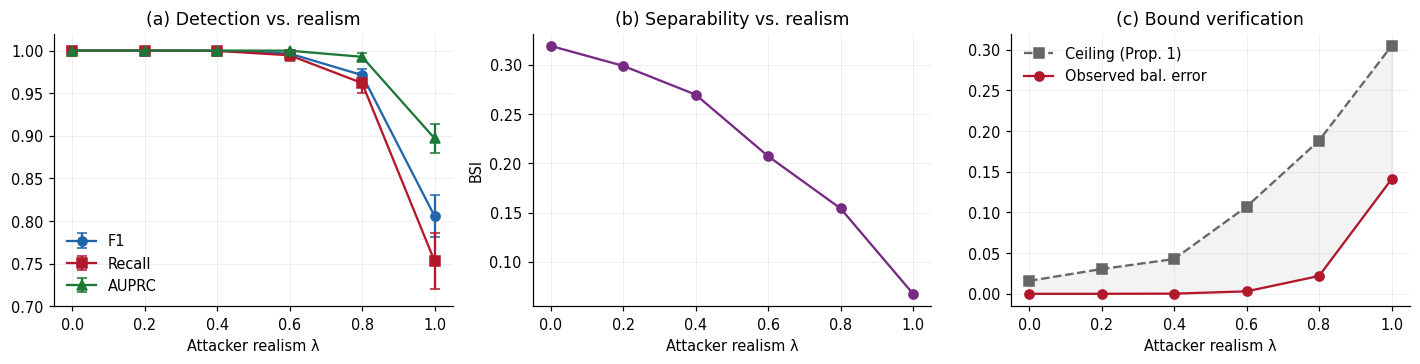

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
a1, a2, a3 = axes
a1.errorbar(e3["lambda"], e3.f1, yerr=e3.f1_std, marker="o", color=BLUE, label="F1", capsize=3)
a1.errorbar(e3["lambda"], e3.recall, yerr=e3.recall_std, marker="s", color=RED, label="Recall", capsize=3)
a1.errorbar(e3["lambda"], e3.auprc, yerr=e3.auprc_std, marker="^", color=GREEN, label="AUPRC", capsize=3)
a1.set_xlabel("Attacker realism λ"); a1.set_ylim(0.7, 1.02); a1.legend(frameon=False)
a1.set_title("(a) Detection vs. realism")
a2.plot(e3["lambda"], e3.BSI, marker="o", color=PURPLE)
a2.set_xlabel("Attacker realism λ"); a2.set_ylabel("BSI"); a2.set_title("(b) Separability vs. realism")
a3.plot(e3["lambda"], e3.ceiling, marker="s", ls="--", color=GRAY, label="Ceiling (Prop. 1)")
a3.plot(e3["lambda"], e3.bal_err, marker="o", color=RED, label="Observed bal. error")
a3.fill_between(e3["lambda"], e3.bal_err, e3.ceiling, color=GRAY, alpha=0.08)
a3.set_xlabel("Attacker realism λ"); a3.legend(frameon=False); a3.set_title("(c) Bound verification")
plt.tight_layout(); plt.savefig(F+"realism_sweep_and_bound.png"); plt.show()

## 14 — Hard-Negative Tests and Per-Profile Performance (E4–E5)

In [12]:
# 14_hard_negative_tests
tr, te = train_test_split(df_main, test_size=0.25, stratify=df_main.label, random_state=2)
rf_hold = models()["RF"].fit(tr[FEATURES], tr.label)
te2 = te.copy(); te2["pred"] = rf_hold.predict(te[FEATURES])
rows = [{"group": p, "n": (te2.profile==p).sum(),
         "recall": te2[te2.profile==p].pred.mean()} for p in ["A0","A1","A2","A3","A4"]]
for hn in sorted(x for x in te2.profile.unique() if x.startswith("HN_")):
    rows.append({"group": hn, "n": (te2.profile==hn).sum(), "fpr": te2[te2.profile==hn].pred.mean()})
ordn = te2[(te2.label==0) & (~te2.profile.str.startswith("HN_"))]
rows.append({"group": "ordinary_normal", "n": len(ordn), "fpr": ordn.pred.mean()})
e4 = pd.DataFrame(rows); e4.to_csv(T+"E4_profile_performance.csv", index=False)
e4.round(3)

,group,n,recall,fpr
0,A0,63,1.000,NaN
1,A1,80,1.000,NaN
2,A2,85,1.000,NaN
3,A3,71,0.887,NaN
4,A4,76,0.605,NaN
5,HN_audit_finance,20,NaN,0.000
6,HN_backup_op,26,NaN,0.000
7,HN_batch_script,25,NaN,0.000
8,HN_curious_newhire,21,NaN,0.000
9,HN_late_admin,24,NaN,0.000


## 15 — Leave-One-Attacker-Strategy-Out Generalization (E6)

In [13]:
# 15_leave_one_strategy_out
rows = []
for held in ["A0","A1","A2","A3","A4"]:
    keep = df_main[(df_main.label==0) | (df_main.profile != held)]
    trn, nte = train_test_split(keep[keep.label==0], test_size=0.3, random_state=3)
    m = models()["RF"].fit(pd.concat([trn, keep[keep.label==1]])[FEATURES],
                            pd.concat([trn, keep[keep.label==1]]).label)
    rows.append({"held_out": held, "lambda": PROFILE_LAMBDA[held],
                 "recall_unseen": m.predict(df_main[df_main.profile==held][FEATURES]).mean(),
                 "fpr_normals": m.predict(nte[FEATURES]).mean()})
e6 = pd.DataFrame(rows); e6.to_csv(T+"E6_leave_one_out.csv", index=False)
e6.round(3)

,held_out,lambda,recall_unseen,fpr_normals
0,A0,0.00,1.000,0.015
1,A1,0.25,1.000,0.014
2,A2,0.45,1.000,0.014
3,A3,0.65,0.903,0.011
4,A4,0.90,0.490,0.002


## 16 — Feature Ablation and Importance (E7)

In [14]:
# 16_feature_ablation
imp = pd.Series(models()["RF"].fit(df_main[FEATURES], df_main.label).feature_importances_,
                index=FEATURES).sort_values(ascending=False)
imp.to_csv(T+"feature_importance.csv"); display(imp.head(8).round(3).to_frame("importance"))

abl = {"full": FEATURES,
  "no_deception": [f for f in FEATURES if f not in FAMILIES["deception"] and f not in FAMILIES["intent"]],
  "no_temporal": [f for f in FEATURES if f not in FAMILIES["temporal"]],
  "no_speed": [f for f in FEATURES if f not in ("nav_speed","mean_dwell","dwell_var","session_duration")],
  "no_intent": [f for f in FEATURES if f not in FAMILIES["intent"]],
  "deception_only": FAMILIES["deception"]+FAMILIES["intent"],
  "behavioral_only": [f for f in FEATURES if f not in ("honey_touches","honey_frac")]}
rows = []
tr_, te_ = train_test_split(df_main, test_size=0.25, stratify=df_main.label, random_state=4)
for name, fs in abl.items():
    r = cv_eval(df_main, feats=fs, model_subset=["RF"]).iloc[0]
    m = models()["RF"].fit(tr_[fs], tr_.label)
    st = te_[te_.profile.isin(["A3","A4"])]
    rows.append({"ablation": name, "n_features": len(fs), "f1": r.f1, "f1_std": r.f1_std,
                 "recall_stealth_A3A4": m.predict(st[fs]).mean()})
    print(f"  {name:16s} F1={r.f1:.3f}  stealth recall={rows[-1]['recall_stealth_A3A4']:.3f}")
e7 = pd.DataFrame(rows); e7.to_csv(T+"E7_ablation.csv", index=False)

,importance
honey_frac,0.273
honey_touches,0.219
hesitation,0.100
nav_speed,0.060
cred_searches,0.060
dir_entropy,0.051
fin_searches,0.046
failed_logins,0.038


  full             F1=0.945  stealth recall=0.815


  no_deception     F1=0.913  stealth recall=0.689


  no_temporal      F1=0.943  stealth recall=0.834


  no_speed         F1=0.936  stealth recall=0.775


  no_intent        F1=0.942  stealth recall=0.834


  deception_only   F1=0.936  stealth recall=0.795


  behavioral_only  F1=0.923  stealth recall=0.755


## 17 — Sequential Early Detection (E8)

The stopping rule $T_{\det} = \inf\{k : \pi_k \ge \tau\}$ with $\tau = 0.5$, on a Random Forest trained on **event-prefix features**. Metrics: time-to-detection (TTD), fraction detected before the first honey-file access, and the early-warning score $\mathrm{EWS} = \pi_{T_{\det}}\,(1 - T_{\det}/N)$.

In [15]:
# 17_sequential_early_detection
tr_idx, te_idx = train_test_split(np.arange(len(sess_main)), test_size=0.25,
    stratify=[s["label"] for s in sess_main], random_state=5)
Xtr, ytr = [], []
for i in tr_idx:
    s = sess_main[i]; L = len(s["events"])
    for k in set([max(1,int(L*f)) for f in (0.2,0.4,0.6,0.8,1.0)] + [min(3,L), min(5,L)]):
        Xtr.append(list(features_from_events(s, upto=k).values())); ytr.append(s["label"])
seq_rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=0, n_jobs=-1).fit(np.array(Xtr), ytr)
pickle.dump(seq_rf, open(MO+"sequential_rf.pkl","wb"))

ttd, ttd_frac, ews, n_att, before_honey, det = [], [], [], 0, 0, 0
conf_att, conf_norm = [], []
for i in te_idx:
    s = sess_main[i]; L = min(len(s["events"]), 40)
    Xk = np.array([list(features_from_events(s, upto=k).values()) for k in range(1, L+1)])
    confs = seq_rf.predict_proba(Xk)[:,1]
    (conf_att if s["label"] else conf_norm).append(
        np.interp(np.linspace(0,1,20), np.linspace(0,1,L), confs))
    hits = np.where(confs >= 0.5)[0]
    if s["label"] == 1:
        n_att += 1
        first_honey = next((j+1 for j,e in enumerate(s["events"]) if e[2]==1), None)
        if len(hits):
            k = int(hits[0])+1; det += 1
            ttd.append(k); ttd_frac.append(k/len(s["events"]))
            ews.append(confs[hits[0]]*(1-k/len(s["events"])))
            if first_honey and k <= first_honey: before_honey += 1
ks = [1,3,5,7,10,15,20,30]
rows = []
for k in ks:
    Xk = np.array([list(features_from_events(sess_main[i], upto=min(k,len(sess_main[i]["events"]))).values()) for i in te_idx])
    yk = np.array([sess_main[i]["label"] for i in te_idx]); pk = seq_rf.predict_proba(Xk)[:,1]
    rows.append({"k": k, "precision": precision_score(yk, pk>=0.5), "recall": recall_score(yk, pk>=0.5),
                 "f1": f1_score(yk, pk>=0.5), "auprc": average_precision_score(yk, pk)})
e8 = pd.DataFrame(rows); e8.to_csv(T+"E8_sequential.csv", index=False)
seq_summary = {"detected_frac": det/n_att, "ttd_median": float(np.median(ttd)),
    "ttd_mean": float(np.mean(ttd)), "ttd_p90": float(np.percentile(ttd,90)),
    "detected_before_first_honey": before_honey/n_att,
    "EWS_mean": float(np.mean(ews)), "EWS_median": float(np.median(ews))}
print(json.dumps(seq_summary, indent=1)); display(e8.round(3))

{
 "detected_frac": 0.9546666666666667,
 "ttd_median": 3.0,
 "ttd_mean": 5.064245810055866,
 "ttd_p90": 9.300000000000011,
 "detected_before_first_honey": 0.8586666666666667,
 "EWS_mean": 0.5308039629000418,
 "EWS_median": 0.5666359782160357
}


,k,precision,recall,f1,auprc
0,1,1.000,0.003,0.005,0.262
1,3,0.630,0.744,0.682,0.615
2,5,0.887,0.651,0.751,0.865
3,7,0.940,0.672,0.784,0.896
4,10,0.928,0.720,0.811,0.912
5,15,0.935,0.771,0.845,0.935
6,20,0.950,0.816,0.878,0.946
7,30,0.949,0.891,0.919,0.977


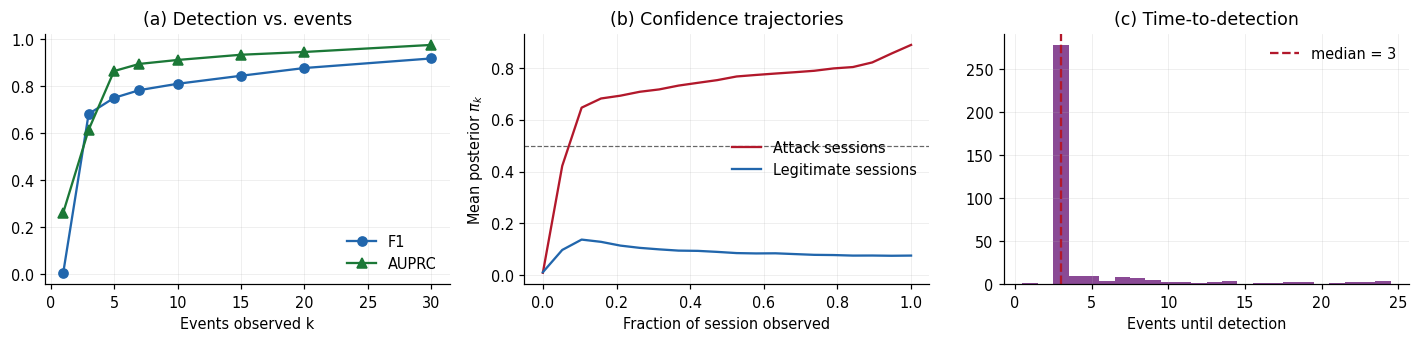

In [16]:
fig, (a1,a2,a3) = plt.subplots(1, 3, figsize=(13, 3.2))
a1.plot(e8.k, e8.f1, marker="o", color=BLUE, label="F1")
a1.plot(e8.k, e8.auprc, marker="^", color=GREEN, label="AUPRC")
a1.set_xlabel("Events observed k"); a1.legend(frameon=False); a1.set_title("(a) Detection vs. events")
frac = np.linspace(0,1,20)
a2.plot(frac, np.mean(conf_att,axis=0), color=RED, label="Attack sessions")
a2.plot(frac, np.mean(conf_norm,axis=0), color=BLUE, label="Legitimate sessions")
a2.axhline(0.5, ls="--", color=GRAY, lw=0.8); a2.set_xlabel("Fraction of session observed")
a2.set_ylabel("Mean posterior $\\pi_k$"); a2.legend(frameon=False); a2.set_title("(b) Confidence trajectories")
a3.hist(ttd, bins=np.arange(0.5,25.5), color=PURPLE, alpha=0.85)
a3.axvline(np.median(ttd), color=RED, ls="--", label=f"median = {np.median(ttd):.0f}")
a3.set_xlabel("Events until detection"); a3.legend(frameon=False); a3.set_title("(c) Time-to-detection")
plt.tight_layout(); plt.savefig(F+"sequential_detection.png"); plt.show()

## 18 — Adversarial Evasion Cost / Attacker Utility

$Y_u(\lambda) = Y(\lambda)\,(1-P_d(\lambda))$: the expected **undetected reconnaissance yield**. Deception succeeds if $Y_u$ stays small everywhere on the continuum — evasion must cost the attacker the very yield that motivated the intrusion.

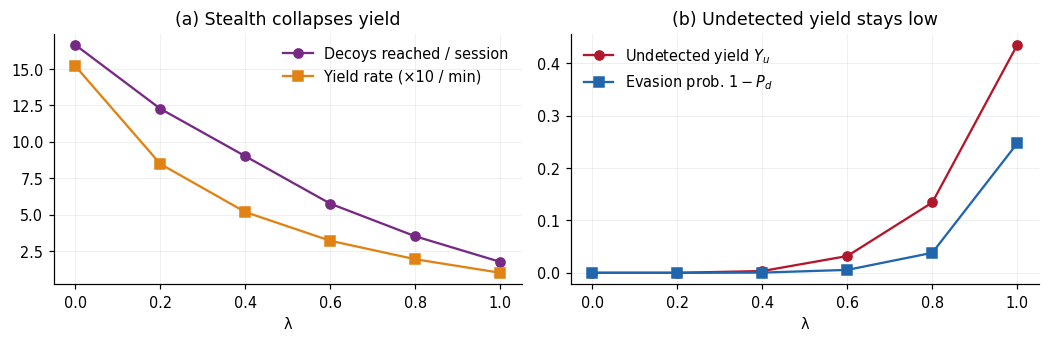

,lambda,P_d,decoys_reached,files_accessed,session_time_s,yield_per_min,undetected_yield
0,0.0,1.000,16.651,30.059,657.286,1.520,0.000
1,0.2,1.000,12.270,25.701,867.814,0.848,0.000
2,0.4,1.000,9.013,21.799,1043.732,0.518,0.003
3,0.6,0.994,5.756,17.280,1075.815,0.321,0.032
4,0.8,0.962,3.517,13.276,1086.147,0.194,0.134
5,1.0,0.753,1.760,9.004,1043.251,0.101,0.435


In [17]:
# 18_adversarial_evasion (behavioral evasion cost)
rows = []
for _, r in e3.iterrows():
    lam = r["lambda"]
    dfl, _ = make_dataset(int(20+lam*10), 3000, [(None, lam, 900)])
    att = dfl[dfl.label==1]
    Y = att.honey_touches.mean(); dur = att.session_duration.mean()
    rows.append({"lambda": lam, "P_d": r["recall"], "decoys_reached": Y,
        "files_accessed": att.n_files.mean(), "session_time_s": dur,
        "yield_per_min": Y/(dur/60), "undetected_yield": Y*(1-r["recall"])})
ev = pd.DataFrame(rows); ev.to_csv(T+"evasion_cost.csv", index=False)
fig,(a1,a2) = plt.subplots(1,2, figsize=(9.5,3.2))
a1.plot(ev["lambda"], ev.decoys_reached, marker="o", color=PURPLE, label="Decoys reached / session")
a1.plot(ev["lambda"], ev.yield_per_min*10, marker="s", color=ORANGE, label="Yield rate (×10 / min)")
a1.set_xlabel("λ"); a1.legend(frameon=False); a1.set_title("(a) Stealth collapses yield")
a2.plot(ev["lambda"], ev.undetected_yield, marker="o", color=RED, label="Undetected yield $Y_u$")
a2.plot(ev["lambda"], 1-ev.P_d, marker="s", color=BLUE, label="Evasion prob. $1-P_d$")
a2.set_xlabel("λ"); a2.legend(frameon=False); a2.set_title("(b) Undetected yield stays low")
plt.tight_layout(); plt.savefig(F+"evasion_cost.png"); plt.show()
ev.round(3)

## 19 — Adaptive Deception: Risk-Conditioned Decoy Escalation (lightweight demonstration)

When the sequential posterior of a session crosses a *soft* threshold $\tau_1 < \tau$, the tiered-response policy deploys additional **contextual (Tier-2) decoys** around the suspicious session. We simulate this by regenerating human-like (A4) sessions in which, from the first event where $\pi_k \ge \tau_1 = 0.25$, remaining file-opens face an escalated decoy density (honey-touch probability $0.45 \to 0.70$). Static deception leaves the environment unchanged. This is a simplified simulation of the closed loop (the full adaptive-attacker analysis is future work in the paper).

In [18]:
# 19_adaptive_deception
def a4_recall(escalate, n=250, tau1=0.25, seed=77):
    rng = RNG(seed); caught = 0
    for _ in range(n):
        s = gen_attacker(rng, "A4"); L = min(len(s["events"]), 40)
        escalated = False
        for k in range(1, L+1):
            if escalated:
                # escalation: benign opens become honey opens with boosted probability
                e = s["events"][k-1]
                if e[0] == "open_benign" and rng.random() < 0.45:
                    s["events"][k-1] = ("open_honey", e[1], 1)
            x = [list(features_from_events(s, upto=k).values())]
            c = seq_rf.predict_proba(x)[0,1]
            if c >= 0.5: caught += 1; break
            if escalate and not escalated and c >= tau1: escalated = True
    return caught/n

r_static = a4_recall(False); r_adapt = a4_recall(True)
adres = pd.DataFrame([{"deception":"static","A4_recall":r_static},
                      {"deception":"adaptive (risk-conditioned)","A4_recall":r_adapt}])
adres.to_csv(T+"adaptive_deception.csv", index=False)
print(f"A4 (human-like) sequential recall — static: {r_static:.3f}   adaptive: {r_adapt:.3f}")
adres

A4 (human-like) sequential recall — static: 0.812   adaptive: 0.820


,deception,A4_recall
0,static,0.812
1,adaptive (risk-conditioned),0.820


## 20 — Probability Calibration

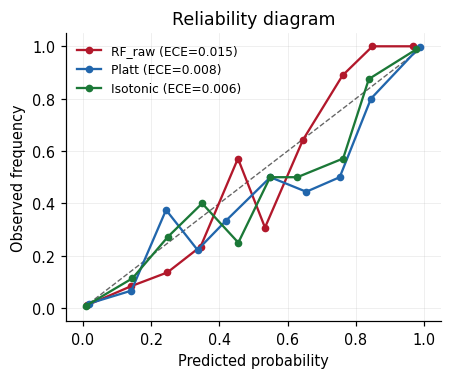

,method,brier,ece
0,RF_raw,0.0234,0.0153
1,Platt,0.0231,0.0085
2,Isotonic,0.0226,0.0065


In [19]:
# 20_calibration
def ece(y, p, n_bins=10):
    b = np.clip((p*n_bins).astype(int), 0, n_bins-1); e = 0
    for i in range(n_bins):
        m = b==i
        if m.sum(): e += m.mean()*abs(y[m].mean()-p[m].mean())
    return e
trc, tec = train_test_split(df_main, test_size=0.25, stratify=df_main.label, random_state=7)
rows, rel = [], {}
for name, cal in [("RF_raw", None), ("Platt", "sigmoid"), ("Isotonic", "isotonic")]:
    base = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=0, n_jobs=-1)
    m = base if cal is None else CalibratedClassifierCV(base, method=cal, cv=5)
    m.fit(trc[FEATURES], trc.label)
    p = m.predict_proba(tec[FEATURES])[:,1]; y = tec.label.values
    rows.append({"method": name, "brier": brier_score_loss(y,p), "ece": ece(y,p)})
    mids, obs, bins = [], [], np.linspace(0,1,11)
    for i in range(10):
        msk = (p>=bins[i])&(p<bins[i+1])
        if msk.sum()>5: mids.append(p[msk].mean()); obs.append(y[msk].mean())
    rel[name] = (mids, obs)
calres = pd.DataFrame(rows); calres.to_csv(T+"calibration.csv", index=False)
fig, ax = plt.subplots(figsize=(4.4,3.4))
ax.plot([0,1],[0,1], ls="--", color=GRAY, lw=0.9)
for (name,(mi,ob)), c in zip(rel.items(), [RED,BLUE,GREEN]):
    e = calres[calres.method==name].iloc[0]
    ax.plot(mi, ob, marker="o", ms=4, color=c, label=f"{name} (ECE={e.ece:.3f})")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
ax.legend(frameon=False, fontsize=8); ax.set_title("Reliability diagram")
plt.savefig(F+"calibration.png"); plt.show()
calres.round(4)

## 21 — Robustness: Class Imbalance and Telemetry Noise

In [20]:
# 21_noise_and_imbalance
rows = []
for prev in [0.20, 0.10, 0.05, 0.01, 0.005]:
    n_att_ = max(30, int(6000*prev/(1-prev))); per = max(6, n_att_//5)
    dfp, _ = make_dataset(int(100+prev*1000), 6000, [(p,None,per) for p in ["A0","A1","A2","A3","A4"]])
    trp, tep = train_test_split(dfp, test_size=0.3, stratify=dfp.label, random_state=8)
    m = models()["RF"].fit(trp[FEATURES], trp.label)
    p = m.predict_proba(tep[FEATURES])[:,1]; y = tep.label.values; pr = (p>=0.5).astype(int)
    rows.append({"prevalence": prev, "precision": precision_score(y,pr,zero_division=0),
        "recall": recall_score(y,pr), "f1": f1_score(y,pr),
        "auprc": average_precision_score(y,p), "false_alerts_per_1000": pr[y==0].mean()*1000})
imb = pd.DataFrame(rows); imb.to_csv(T+"imbalance.csv", index=False); display(imb.round(3))

trn_, ten_ = train_test_split(df_main, test_size=0.25, stratify=df_main.label, random_state=9)
mnoise = models()["RF"].fit(trn_[FEATURES], trn_.label)
med = trn_[FEATURES].median(); rows = []; rngn = np.random.default_rng(12)
for rate in [0.0, 0.05, 0.10, 0.20, 0.30]:
    Xc = ten_[FEATURES].astype(float).copy()
    for f in FEATURES:
        msk = rngn.random(len(Xc)) < rate; Xc.loc[msk, f] = float(med[f])
        jit = rngn.random(len(Xc)) < rate
        Xc.loc[jit, f] = Xc.loc[jit, f] * rngn.normal(1, 0.15, jit.sum())
    pr = mnoise.predict(Xc); y = ten_.label.values
    rows.append({"corruption": rate, "precision": precision_score(y,pr),
                 "recall": recall_score(y,pr), "f1": f1_score(y,pr)})
noi = pd.DataFrame(rows); noi.to_csv(T+"noise.csv", index=False); noi.round(3)

,prevalence,precision,recall,f1,auprc,false_alerts_per_1000
0,0.200,0.977,0.936,0.956,0.989,5.556
1,0.100,0.966,0.860,0.910,0.958,3.333
2,0.050,0.965,0.874,0.917,0.955,1.667
3,0.010,1.000,0.833,0.909,0.943,0.000
4,0.005,1.000,0.667,0.800,0.766,0.000


,corruption,precision,recall,f1
0,0.00,0.959,0.939,0.949
1,0.05,0.958,0.920,0.939
2,0.10,0.959,0.877,0.916
3,0.20,0.975,0.821,0.891
4,0.30,0.960,0.768,0.853


## 22 — Statistical Tests

Paired comparison of per-fold CV scores (identical folds) between Random Forest and logistic regression on the main dataset — is the ensemble's advantage statistically meaningful?

In [21]:
# 22_statistical_tests
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
X, y = df_main[FEATURES].values, df_main.label.values
f_rf = cross_validate(models()["RF"], X, y, cv=cv, scoring="f1", n_jobs=-1)["test_score"]
f_lr = cross_validate(models()["LogReg"], X, y, cv=cv, scoring="f1", n_jobs=-1)["test_score"]
t, p_t = scistats.ttest_rel(f_rf, f_lr); w, p_w = scistats.wilcoxon(f_rf, f_lr)
print(f"RF F1 = {f_rf.mean():.4f} ± {f_rf.std():.4f}   LogReg F1 = {f_lr.mean():.4f} ± {f_lr.std():.4f}")
print(f"paired t-test p = {p_t:.3f}   Wilcoxon p = {p_w:.3f}")
print("=> On overlapping data, RF's advantage over a linear model is small — separability,"
      " not classifier complexity, governs performance (the paper's central thesis).")

RF F1 = 0.9450 ± 0.0104   LogReg F1 = 0.9438 ± 0.0112
paired t-test p = 0.536   Wilcoxon p = 0.551
=> On overlapping data, RF's advantage over a linear model is small — separability, not classifier complexity, governs performance (the paper's central thesis).


## 23–24 — Consolidated Tables and Publication Figures

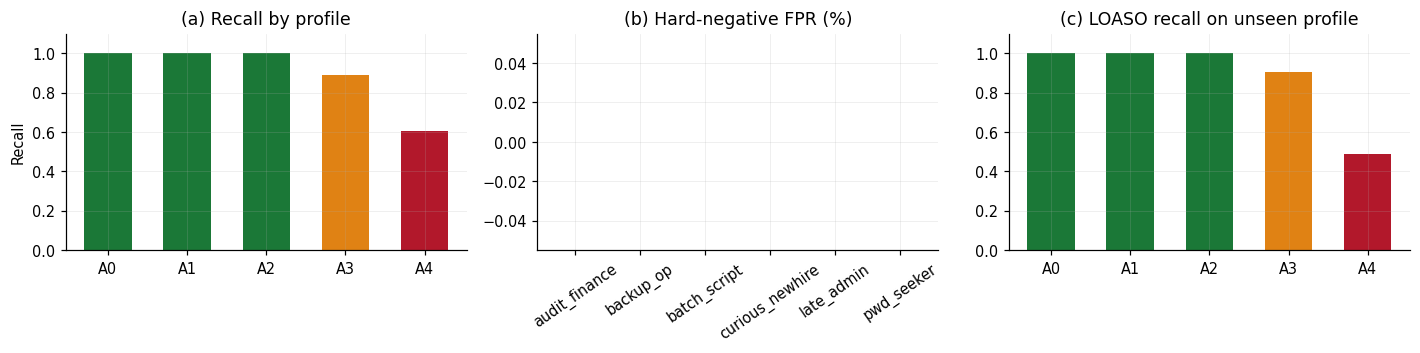

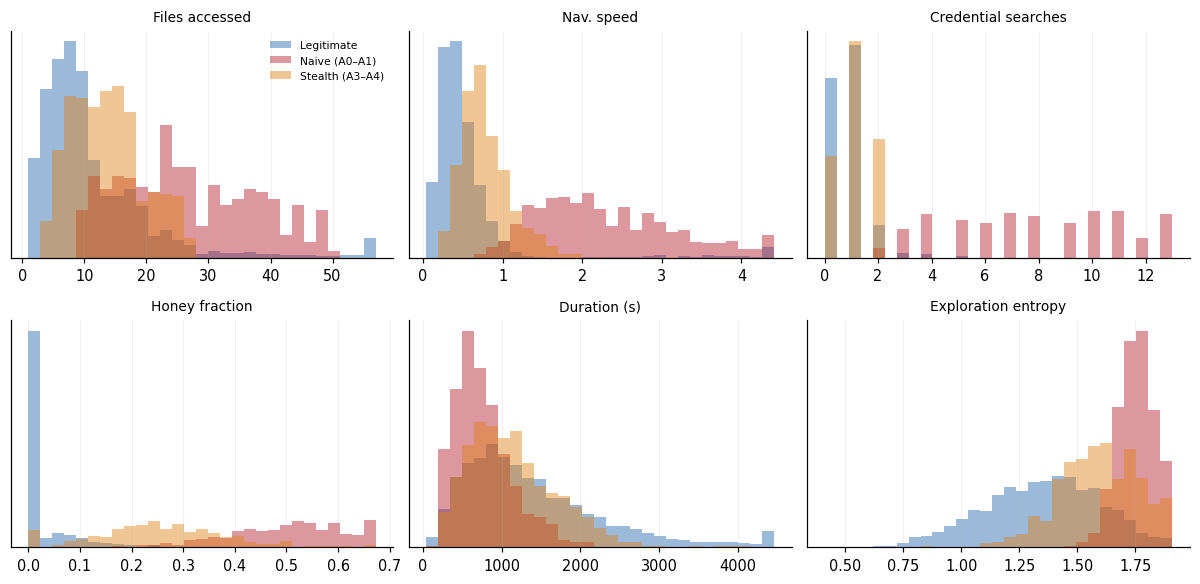

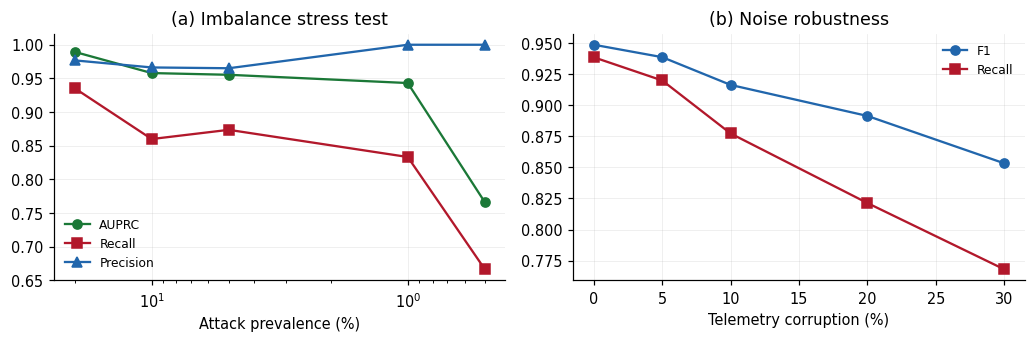

In [22]:
# 23_generate_tables / 24_generate_figures
# Per-profile & LOASO figure
prof = e4[e4.group.str.match("A[0-4]")]; hns = e4[e4.group.str.startswith("HN_")]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
axes[0].bar(prof.group, prof.recall, color=[GREEN]*3+[ORANGE,RED], width=0.6)
axes[0].set_ylim(0,1.1); axes[0].set_title("(a) Recall by profile"); axes[0].set_ylabel("Recall")
axes[1].bar([g.replace("HN_","") for g in hns.group], hns.fpr*100, color=BLUE, width=0.6)
axes[1].tick_params(axis="x", rotation=35); axes[1].set_title("(b) Hard-negative FPR (%)")
axes[2].bar(e6.held_out, e6.recall_unseen, color=[GREEN]*3+[ORANGE,RED], width=0.6)
axes[2].set_ylim(0,1.1); axes[2].set_title("(c) LOASO recall on unseen profile")
plt.tight_layout(); plt.savefig(F+"profiles_loaso.png"); plt.show()

# Feature distributions figure
feats6 = [("n_files","Files accessed"),("nav_speed","Nav. speed"),("cred_searches","Credential searches"),
          ("honey_frac","Honey fraction"),("session_duration","Duration (s)"),("dir_entropy","Exploration entropy")]
groups = [(df_main[df_main.label==0],"Legitimate",BLUE),
          (df_main[df_main.profile.isin(["A0","A1"])],"Naive (A0–A1)",RED),
          (df_main[df_main.profile.isin(["A3","A4"])],"Stealth (A3–A4)",ORANGE)]
fig, axes = plt.subplots(2, 3, figsize=(11, 5.4))
for ax,(f,t) in zip(axes.flat, feats6):
    hi = np.percentile(df_main[f], 99); bins = np.linspace(df_main[f].min(), max(hi,1e-6), 30)
    for g, lab, c in groups: ax.hist(np.clip(g[f],None,hi), bins=bins, density=True, alpha=0.45, color=c, label=lab)
    ax.set_title(t, fontsize=9); ax.set_yticks([])
axes[0,0].legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.savefig(F+"distributions.png"); plt.show()

fig,(a1,a2) = plt.subplots(1,2, figsize=(9.5,3.2))
a1.semilogx(imb.prevalence*100, imb.auprc, marker="o", color=GREEN, label="AUPRC")
a1.semilogx(imb.prevalence*100, imb.recall, marker="s", color=RED, label="Recall")
a1.semilogx(imb.prevalence*100, imb.precision, marker="^", color=BLUE, label="Precision")
a1.invert_xaxis(); a1.set_xlabel("Attack prevalence (%)"); a1.legend(frameon=False, fontsize=8)
a1.set_title("(a) Imbalance stress test")
a2.plot(noi.corruption*100, noi.f1, marker="o", color=BLUE, label="F1")
a2.plot(noi.corruption*100, noi.recall, marker="s", color=RED, label="Recall")
a2.set_xlabel("Telemetry corruption (%)"); a2.legend(frameon=False, fontsize=8)
a2.set_title("(b) Noise robustness")
plt.tight_layout(); plt.savefig(F+"robustness.png"); plt.show()

## 25 — Summary of Outputs

In [23]:
# 25_outputs_summary
summary = {
 "datasets": {"easy": list(df_easy.shape), "main": list(df_main.shape)},
 "BSI": {"easy": round(BSI_easy,3), "main": round(BSI_main,3)},
 "E1_all_models_F1": dict(zip(e1.model, e1.f1.round(3))),
 "E2_all_models_F1": dict(zip(e2.model, e2.f1.round(3))),
 "realism_sweep_F1": dict(zip(e3["lambda"], e3.f1.round(3))),
 "prop1_ceiling_holds": bool((e3.bal_err <= e3.ceiling + 1e-9).all()),
 "A4_recall_holdout": round(float(e4[e4.group=="A4"].recall.iloc[0]),3),
 "A4_recall_LOASO": round(float(e6[e6.held_out=="A4"].recall_unseen.iloc[0]),3),
 "sequential": seq_summary,
 "adaptive_vs_static_A4": {"static": round(r_static,3), "adaptive": round(r_adapt,3)},
 "calibration_ECE": dict(zip(calres.method, calres.ece.round(4))),
 "undetected_yield_max": round(float(ev.undetected_yield.max()),3),
}
with open(os.path.join(ROOT, "Outputs_Summary.txt"), "w") as f:
    f.write(json.dumps(summary, indent=1))
print(json.dumps(summary, indent=1))
print("\nAll outputs written under:", ROOT)

{
 "datasets": {
  "easy": [
   1625,
   21
  ],
  "main": [
   5500,
   21
  ]
 },
 "BSI": {
  "easy": 0.444,
  "main": 0.166
 },
 "E1_all_models_F1": {
  "LogReg": 1.0,
  "RF": 1.0,
  "SVM-RBF": 1.0,
  "MLP": 0.996
 },
 "E2_all_models_F1": {
  "LogReg": 0.944,
  "RF": 0.945,
  "SVM-RBF": 0.949,
  "MLP": 0.943
 },
 "realism_sweep_F1": {
  "0.0": 1.0,
  "0.2": 1.0,
  "0.4": 1.0,
  "0.6": 0.996,
  "0.8": 0.971,
  "1.0": 0.806
 },
 "prop1_ceiling_holds": true,
 "A4_recall_holdout": 0.605,
 "A4_recall_LOASO": 0.49,
 "sequential": {
  "detected_frac": 0.9546666666666667,
  "ttd_median": 3.0,
  "ttd_mean": 5.064245810055866,
  "ttd_p90": 9.300000000000011,
  "detected_before_first_honey": 0.8586666666666667,
  "EWS_mean": 0.5308039629000418,
  "EWS_median": 0.5666359782160357
 },
 "adaptive_vs_static_A4": {
  "static": 0.812,
  "adaptive": 0.82
 },
 "calibration_ECE": {
  "RF_raw": 0.0153,
  "Platt": 0.0085,
  "Isotonic": 0.0065
 },
 "undetected_yield_max": 0.435
}

All outputs written unde